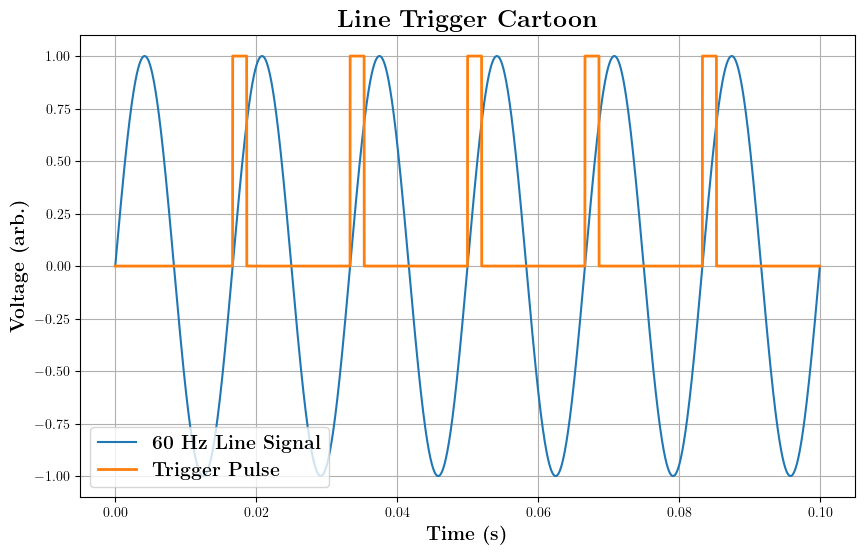

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fs = 100000         
duration = 0.1  
f_line = 60         
pulse_width = 0.002  


t = np.linspace(0, duration, int(fs * duration), endpoint=False)

line_signal = np.sin(2 * np.pi * f_line * t)


zero_crossings = np.where(
    (line_signal[:-1] < 0) & (line_signal[1:] >= 0)
)[0]


trigger = np.zeros_like(t)
pulse_samples = int(pulse_width * fs)

for idx in zero_crossings:
    trigger[idx:idx + pulse_samples] = 1


plt.figure(figsize=(10, 6))

plt.plot(t, line_signal, label=r"\textbf{60 Hz Line Signal}")
plt.plot(t, trigger, label=r"\textbf{Trigger Pulse}", linewidth=2)

plt.xlabel(r"\textbf{Time (s)}", fontsize = 14)
plt.ylabel(r"\textbf{Voltage (arb.)}", fontsize = 14)
plt.title(r"\textbf{Line Trigger Cartoon}", fontsize = 18)
plt.legend(fontsize = 14)
plt.grid(True)

plt.show()


In [2]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

def B_rel_line_mG(t):
    return B_line_mG(t) - B_line_mG(0)

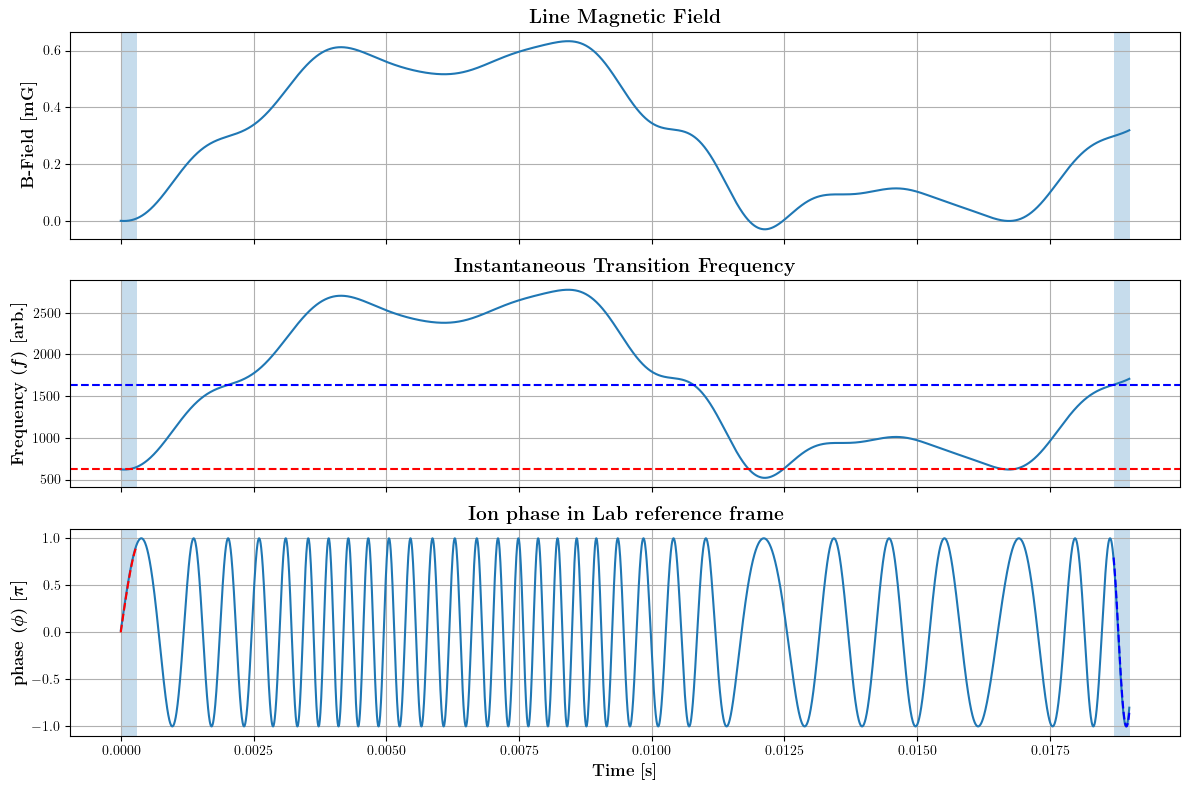

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fs = 200000
duration = 19000e-6
f0 = 623.3
gamma = 3.4e3
pulse_width = 300e-6
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

B_t = B_rel_line_mG(t)
# B_t = 0*np.linspace(0, duration, int(fs * duration), endpoint=False)

delta_t = gamma * B_t
f_inst = f0 + delta_t


phase = 2 * np.pi * np.cumsum(f_inst) / fs
signal = np.sin(phase)


pulse1_start = 0
pulse1_end = pulse_width

pulse2_start = duration - pulse_width
pulse2_end = duration

f_LO1 = f_inst[0]                 
f_LO2 = f0 + gamma*B_rel_line_mG(pulse2_start)##f_inst[-1]             

LO1 = np.zeros_like(t)
LO2 = np.zeros_like(t)
LO_dummy = np.zeros_like(t)
mask1 = (t >= pulse1_start) & (t <= pulse1_end)
mask2 = (t >= pulse2_start) & (t <= pulse2_end)
mask_dummy1 = (t >= pulse1_end) & (t <= pulse2_start)
mask_dummy2 = (t >= 0) & (t <= pulse2_start)

# LO1[mask1] = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
# LO2[mask2] = np.sin(2 * np.pi * f_LO2 * t[mask2] + 0*2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
# LO_dummy[mask_dummy] = np.sin(2 * np.pi * f_LO1 * t[mask_dummy] + 0)

LO1 = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
LO2 = np.sin(2 * np.pi * f_LO2 * t[mask2] + 2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 1*2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
LO_dummy1 = np.sin(2 * np.pi * f_LO1 * t[mask_dummy1] + 0)
LO_dummy2 = np.sin(2 * np.pi * f_LO2 * t[mask_dummy2] + 0)

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)


axs[0].plot(t, B_t)
axs[0].set_title(r"\textbf{Line Magnetic Field}", fontsize = 14)
axs[0].set_ylabel(r"\textbf{B-Field [mG]}", fontsize = 12)
axs[0].grid(True)

axs[1].plot(t, f_inst)
axs[1].axhline(f_LO1, linestyle='--', color = 'red')
axs[1].axhline(f_LO2, linestyle='--', color = 'blue')
axs[1].set_title(r"\textbf{Instantaneous Transition Frequency}", fontsize = 14)
axs[1].set_ylabel(r"\textbf{Frequency (\boldmath$f$) [arb.]}",  fontsize = 12)
axs[1].grid(True)

axs[2].plot(t, signal, label="Ion (Chirped)")
axs[2].plot(t[mask1], LO1, linestyle='--', label="LO @ first pulse", color = 'red')
axs[2].plot(t[mask2], LO2, linestyle='--', label="LO @ second pulse", color = 'blue')
# axs[2].plot(t[mask_dummy1], LO_dummy1, linestyle='--',  color = 'red', linewidth=0.75)
# axs[2].plot(t[mask_dummy2], LO_dummy2, linestyle='--',  color = 'blue', linewidth=0.75)
axs[2].set_title(r"\textbf{Ion phase in Lab reference frame}", fontsize = 14)
axs[2].set_xlabel(r"\textbf{Time [s]}", fontsize = 12)
axs[2].set_ylabel(r"\textbf{phase (\boldmath$\phi$) [\boldmath$\pi$]}", fontsize = 12)
axs[2].grid(True)
# axs[2].legend()


for ax in axs:
    ax.axvspan(pulse1_start, pulse1_end, alpha=0.25)
    ax.axvspan(pulse2_start, pulse2_end, alpha=0.25)

plt.tight_layout()
plt.show()


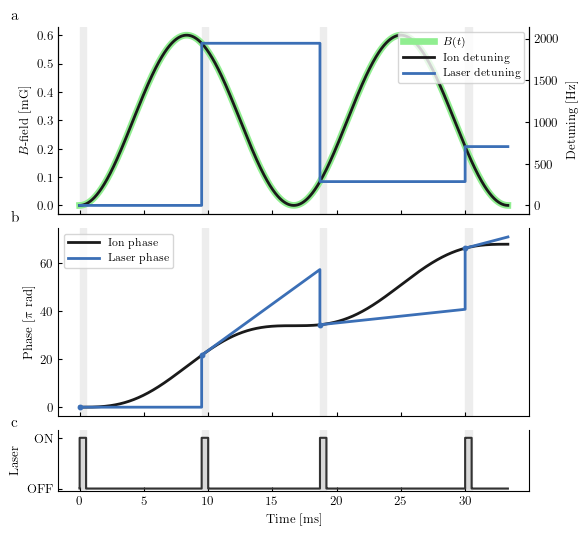

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    30000e-6,
], dtype=float)


pulse_width = 300e-6

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

first_update_index = 1

if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t


B_t = B_rel_line_mG(t)          # [mG]
B_t = -0.3 * np.cos(2 * np.pi * 60 * t) + 0.3 
B_t = B_t - B_t[0]
delta_ion = gamma * B_t         # ion detuning [Hz]
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

laser_detuning = np.zeros_like(t)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    mask = (t >= t0) & (t < t1 if j + 1 < len(pulse_times) else t <= t1)
    laser_detuning[mask] = delta_pulses[j]

phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0  

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):

    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # ms
phase_laser_plot = np.array(phase_laser_plot)    # rad

laser_on = np.zeros_like(t)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on[(t >= t0) & (t < t1)] = 1

c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"


fig, axs = plt.subplots(
    3, 1,
    figsize=(6.2, 5.4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.65]}
)

ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_ms, B_t, color='lightgreen', lw=4.8, label=r"$B(t)$")
ax_r.plot(t_ms, delta_ion, color=c_ion, lw=2.0, label=r"Ion detuning")
ax_r.step(t_ms, laser_detuning, where="post", color=c_laser, lw=2.0, label=r"Laser detuning")

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper right", frameon=True, fontsize=8, handlelength=2.8)

ax = axs[1]
ax.plot(t_ms, phi_ion / np.pi, color=c_ion, lw=2.0, label=r"Ion phase")
ax.plot(phase_t_plot, phase_laser_plot / np.pi, color=c_laser, lw=2.0, label=r"Laser phase")

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=True, fontsize=8, handlelength=2.8)

ax = axs[2]
ax.step(t_ms, laser_on, where="post", color="0.2", lw=1.5)
ax.fill_between(t_ms, 0, laser_on, step="post", color="0.85")

ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Laser")
ax.set_xlabel(r"Time [ms]")

for i, ax in enumerate(axs):
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf")
plt.show()

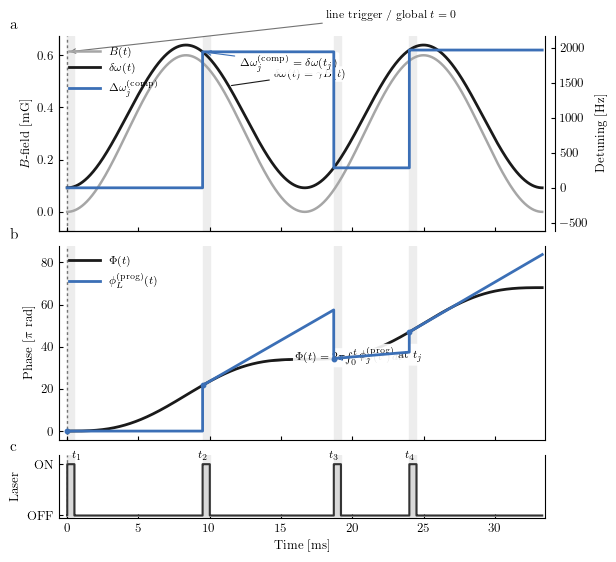

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------
# Parameters
# -----------------------
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

# first pulse is reference; compensation updates start from next pulse
first_update_index = 1

# -----------------------
# Helpers
# -----------------------
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.9)

# -----------------------
# Pulse checks
# -----------------------
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# -----------------------
# Time axis
# -----------------------
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# -----------------------
# Field, detuning, phase
# -----------------------
# B_t = B_rel_line_mG(t)
B_t = -0.3 * np.cos(2 * np.pi * 60 * t) + 0.3
B_t = B_t - B_t[0]

delta_ion = gamma * B_t                                # Hz
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # rad

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# -----------------------
# Piecewise laser detuning
# -----------------------
laser_detuning = np.zeros_like(t)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t >= t0) & (t < t1)
    else:
        mask = (t >= t0) & (t <= t1)
    laser_detuning[mask] = delta_pulses[j]

# -----------------------
# Piecewise laser phase
# -----------------------
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # ms
phase_laser_plot = np.array(phase_laser_plot) # rad

# -----------------------
# Laser ON/OFF
# -----------------------
laser_on = np.zeros_like(t)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on[(t >= t0) & (t < t1)] = 1

# -----------------------
# Colors
# -----------------------
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "0.45"

# -----------------------
# Plot
# -----------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.6),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.65]}
)

# -------- Panel 1 --------
ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_ms, B_t, color=c_B, lw=1.8, label=r"$B(t)$", zorder=2)
ax_r.plot(
    t_ms, delta_ion, color=c_ion, lw=2.0,
    label=r"$\delta\omega(t)$", zorder=3
)
ax_r.step(
    t_ms, laser_detuning, where="post", color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

# left axis: standard padding
ax.set_ylim(*padded_limits(B_t, low_pad=0.12, high_pad=0.12))

# right axis: asymmetric padding to visually separate proportional traces
ax_r.set_ylim(*padded_limits(delta_ion, low_pad=0.30, high_pad=0.06))
ax_r.spines["right"].set_position(("outward", 7))

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# Representative annotations
idx_det = int(0.34 * len(t))
ax_r.annotate(
    r"$\delta\omega(t)=\gamma B(t)$",
    xy=(t_ms[idx_det], delta_ion[idx_det]),
    xytext=(t_ms[idx_det] + 3.2, delta_ion[idx_det] + 130),
    arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
    fontsize=8,
    bbox=label_box,
)

if first_update_index < len(pulse_times):
    j0 = first_update_index
    ax_r.annotate(
        r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
        xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
        xytext=(1e3 * pulse_times[j0] + 2.6, delta_pulses[j0] - 210),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
        fontsize=8,
        bbox=label_box,
    )

# -------- Panel 2 --------
ax = axs[1]
ax.plot(
    t_ms, phi_ion / np.pi, color=c_ion, lw=2.0,
    label=r"$\Phi(t)$", zorder=3
)
ax.plot(
    phase_t_plot, phase_laser_plot / np.pi, color=c_laser, lw=2.0,
    label=r"$\phi_L^{(\mathrm{prog})}(t)$", zorder=4
)
ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2, zorder=5)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

idx_phi = int(0.42 * len(t))
ax.annotate(
    r"$\Phi(t)=2\pi\!\int_0^t \delta\omega(t')\,dt'$",
    xy=(t_ms[idx_phi], phi_ion[idx_phi] / np.pi),
    xytext=(t_ms[idx_phi] + 2.0, phi_ion[idx_phi] / np.pi + 0.10),
    arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
    fontsize=8,
    bbox=label_box,
)

if first_update_index < len(pulse_times):
    j1 = min(first_update_index + 1, len(pulse_times) - 1)
    ax.annotate(
        r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
        xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
        xytext=(1e3 * pulse_times[j1] + 1.8, phi_pulses[j1] / np.pi + 0.18),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
        fontsize=8,
        bbox=label_box,
    )

# -------- Panel 3 --------
ax = axs[2]
ax.step(t_ms, laser_on, where="post", color="0.2", lw=1.5, zorder=3)
ax.fill_between(t_ms, 0, laser_on, step="post", color="0.85", zorder=2)

ax.set_ylim(-0.05, 1.18)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Laser")
ax.set_xlabel(r"Time [ms]")

# pulse-time labels
for j, t0 in enumerate(pulse_times[1:], start=2):
    ax.text(1e3 * t0, 1.07, rf"$t_{{{j}}}$", ha="center", va="bottom", fontsize=8)

# keep first pulse label off to avoid overlap with trigger label
ax.text(1e3 * pulse_times[0] + 0.35, 1.07, r"$t_1$", ha="left", va="bottom", fontsize=8)

# -----------------------
# Shared styling
# -----------------------
for i, ax in enumerate(axs):
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # global line-trigger reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (2, 2)), zorder=1)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

axs[0].annotate(
    r"line trigger / global $t=0$",
    xy=(0.0, 0.92),
    xycoords=("data", "axes fraction"),
    xytext=(0.55, 1.08),
    textcoords=("axes fraction", "axes fraction"),
    arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
    fontsize=8,
    ha="left",
    va="bottom",
    bbox=label_box,
)

ax_r.spines["top"].set_visible(False)

# a little room to the left so the t=0 trigger is visually obvious
for ax in axs:
    ax.set_xlim(-0.6, t_ms[-1] + 0.2)

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

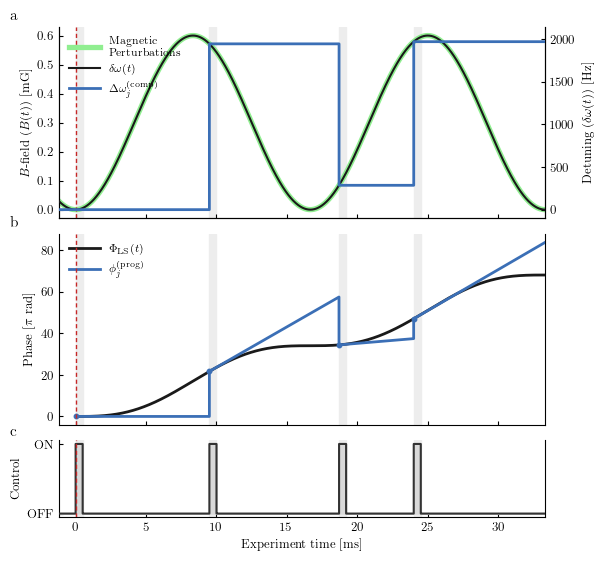

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False   # set True to show theory labels / arrows
USE_TOY_BFIELD = True      # set False to use B_rel_line_mG(...)
SHOW_LINE_TRIGGER = False
# extra time shown before t=0 (for B-field + detuning + trigger only)
pre_trigger_duration = 1.2e-3   # [s]

# line trigger pulse shown in red in last panel
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG   (plays the role of \kappa in the theory text)

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

# first pulse is reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# =========================================================
# TIME AXES
# =========================================================
# full axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# phase axis starts at t=0 only
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# reference everything to the line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

# use only t >= 0 for phase accumulation
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

# sampled values at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# LASER DETUNING: piecewise constant, defined on full axis
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# LASER PHASE: piecewise linear + snaps, plotted only for t >= 0
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # [ms]
phase_laser_plot = np.array(phase_laser_plot)    # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

# red line-trigger pulse before t=0
trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.80]}
)

# ---------------------------------------------------------
# Panel 1: B-field + detuning
# ---------------------------------------------------------
ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_full_ms, B_t_full, color='lightgreen', lw=3.8, label="Magnetic \n Perturbations", zorder=2, alpha = 1)

ax_r.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax_r.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

# asymmetric axis padding so the proportional traces don't visually overlap
# ax.set_ylim(*padded_limits(B_t_full, low_pad=0.12, high_pad=0.14))
# ax_r.set_ylim(*padded_limits(delta_ion_full, low_pad=0.48, high_pad=0.08))
# ax_r.spines["right"].set_position(("outward", 8))

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax_r.set_ylabel(r"Detuning ($\delta\omega(t)$) [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 2: phase (no negative-time phase shown)
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2, zorder=5)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: experiment time / trigger + laser
# ---------------------------------------------------------
ax = axs[2]

# laser pulses
ax.step(t_full_ms, laser_on_full, where="post", color="0.20", lw=1.5, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.85", zorder=2)

# red line trigger before t=0
if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.6, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

# ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")
ax.set_xlabel(r"Experiment time [ms]")

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # pulse shading for experiment pulses
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # red dashed t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

# leave visible room before t=0
for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL THEORY ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    # Panel 1
    idx1 = int(0.22 * len(t_full))
    axs[0].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idx1], B_t_full[idx1]),
        xytext=(t_full_ms[idx1] + 2.0, B_t_full[idx1] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idx2 = int(0.35 * len(t_full))
    ax_r.annotate(
        r"$\delta\omega(t)=\gamma B(t)$",
        xy=(t_full_ms[idx2], delta_ion_full[idx2]),
        xytext=(t_full_ms[idx2] + 2.5, delta_ion_full[idx2] + 130),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if first_update_index < len(pulse_times):
        j0 = first_update_index
        ax_r.annotate(
            r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
            xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
            xytext=(1e3 * pulse_times[j0] + 2.0, delta_pulses[j0] - 180),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    # Panel 2
    idx3 = int(0.45 * len(t))
    axs[1].annotate(
        r"$\Phi_{\mathrm{LS}}(t)=2\pi \!\int_0^t \delta\omega(t')\,dt'$",
        xy=(t_ms[idx3], phi_ion[idx3] / np.pi),
        xytext=(t_ms[idx3] + 1.5, phi_ion[idx3] / np.pi + 0.10),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if len(pulse_times) > first_update_index:
        j1 = min(first_update_index + 1, len(pulse_times) - 1)
        axs[1].annotate(
            r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
            xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
            xytext=(1e3 * pulse_times[j1] + 1.5, phi_pulses[j1] / np.pi + 0.15),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    # Panel 3
    axs[2].annotate(
        r"line trigger",
        xy=(-0.5 * 1e3 * trigger_width, 1.0),
        xytext=(0.7, 0.72),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

    axs[2].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.20, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

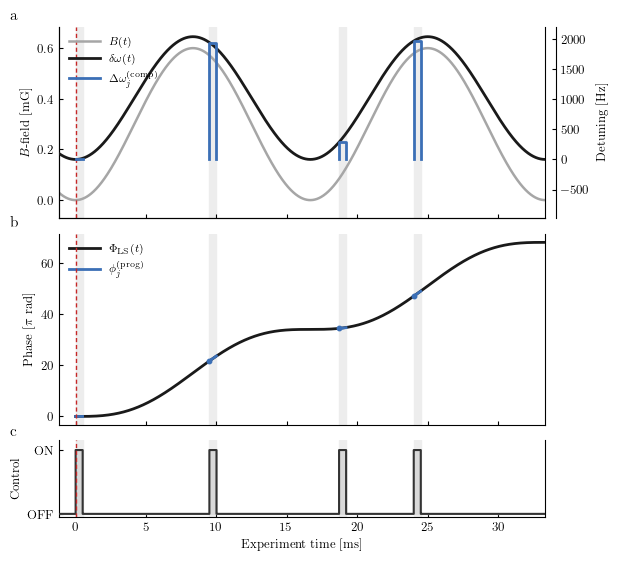

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

# =========================================================
# STYLE
# =========================================================
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# USER TOGGLES
# =========================================================
SHOW_ANNOTATIONS = False
SHOW_TRIGGER_SQUARE_WAVE = False
LASER_TRACE_ONLY_DURING_PULSES = True
USE_TOY_BFIELD = True

# Extra time shown before t=0 (only for B-field, detuning, trigger panel)
pre_trigger_duration = 1.2e-3   # [s]

# Width of red line-trigger pulse before t=0
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)

# Either scalar or array
pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

# First pulse is reference; updates start from the next pulse
first_update_index = 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have same length as pulse_times")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration")

# =========================================================
# TIME AXES
# =========================================================
# Full time axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# Phase is only shown for t >= 0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING / PHASE
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference everything to the line trigger at t = 0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

# Use only t >= 0 for accumulated phase
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)  # [rad]

# Sample at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# LASER DETUNING DISPLAY
# =========================================================
# Base "held-between-updates" detuning
laser_detuning_full_hold = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full_hold[mask] = delta_pulses[j]

if LASER_TRACE_ONLY_DURING_PULSES:
    detuning_t_plot = []
    detuning_y_plot = []

    for j, (t0, w) in enumerate(zip(pulse_times, pulse_widths)):
        t1 = min(t0 + w, duration)
        det = 0.0 if j < first_update_index else delta_pulses[j]

        # Only show during pulse window
        detuning_t_plot.extend([t0, t0, t1, t1, np.nan])
        detuning_y_plot.extend([0.0, det, det, 0.0, np.nan])

    detuning_t_plot = 1e3 * np.array(detuning_t_plot)
    detuning_y_plot = np.array(detuning_y_plot)
else:
    laser_detuning_full = laser_detuning_full_hold

# =========================================================
# LASER PHASE DISPLAY
# =========================================================
marker_mask = np.arange(len(pulse_times)) >= first_update_index
laser_phase_marker_times_ms = 1e3 * pulse_times[marker_mask]
laser_phase_marker_vals = phi_pulses[marker_mask]

if LASER_TRACE_ONLY_DURING_PULSES:
    phase_t_plot = []
    phase_laser_plot = []

    for j, (t0, w) in enumerate(zip(pulse_times, pulse_widths)):
        t1 = min(t0 + w, duration)

        phi_start = 0.0 if j < first_update_index else phi_pulses[j]
        det = 0.0 if j < first_update_index else delta_pulses[j]
        phi_end = phi_start + 2 * np.pi * det * (t1 - t0)

        # Only show phase while laser is on
        phase_t_plot.extend([t0, t1, np.nan])
        phase_laser_plot.extend([phi_start, phi_end, np.nan])

    phase_t_plot = 1e3 * np.array(phase_t_plot)
    phase_laser_plot = np.array(phase_laser_plot)

else:
    # Continuous piecewise-linear phase + snaps
    phase_t_plot = [0.0]
    phase_laser_plot = [0.0]

    current_t = 0.0
    current_phi = 0.0
    current_detuning = 0.0

    update_times = pulse_times[first_update_index:]

    for k, t_update in enumerate(update_times):
        phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

        phase_t_plot.extend([t_update])
        phase_laser_plot.extend([phi_before])

        pulse_idx = first_update_index + k
        phi_snap = phi_pulses[pulse_idx]

        phase_t_plot.extend([t_update])
        phase_laser_plot.extend([phi_snap])

        current_t = t_update
        current_phi = phi_snap
        current_detuning = delta_pulses[pulse_idx]

    phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
    phase_t_plot.extend([duration])
    phase_laser_plot.extend([phi_end])

    phase_t_plot = 1e3 * np.array(phase_t_plot)
    phase_laser_plot = np.array(phase_laser_plot)

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.80]}
)

# ---------------------------------------------------------
# Panel 1: B-field + detuning
# ---------------------------------------------------------
ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_full_ms, B_t_full, color=c_B, lw=1.8, label=r"$B(t)$", zorder=2)

ax_r.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=2.0,
    label=r"$\delta\omega(t)$", zorder=3
)

if LASER_TRACE_ONLY_DURING_PULSES:
    ax_r.plot(
        detuning_t_plot, detuning_y_plot,
        color=c_laser, lw=2.0,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )
else:
    ax_r.step(
        t_full_ms, laser_detuning_full,
        where="post",
        color=c_laser, lw=2.0,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )

# Asymmetric padding so proportional traces don't sit on top of each other
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.12, high_pad=0.14))
ax_r.set_ylim(*padded_limits(delta_ion_full, low_pad=0.48, high_pad=0.08))
ax_r.spines["right"].set_position(("outward", 8))

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 2: phase
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

if len(laser_phase_marker_times_ms) > 0:
    ax.plot(
        laser_phase_marker_times_ms,
        laser_phase_marker_vals / np.pi,
        "o", color=c_laser, ms=3.2, zorder=5
    )

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: experiment time / trigger + laser
# ---------------------------------------------------------
ax = axs[2]

# Laser pulses
ax.step(t_full_ms, laser_on_full, where="post", color="0.20", lw=1.5, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.85", zorder=2)

# Optional trigger square wave before t=0
if SHOW_TRIGGER_SQUARE_WAVE:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.6, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")
ax.set_xlabel(r"Experiment time [ms]")

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # Pulse shading
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # Red dashed t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    idx1 = int(0.22 * len(t_full))
    axs[0].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idx1], B_t_full[idx1]),
        xytext=(t_full_ms[idx1] + 2.0, B_t_full[idx1] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idx2 = int(0.35 * len(t_full))
    ax_r.annotate(
        r"$\delta\omega(t)=\gamma B(t)$",
        xy=(t_full_ms[idx2], delta_ion_full[idx2]),
        xytext=(t_full_ms[idx2] + 2.5, delta_ion_full[idx2] + 130),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if first_update_index < len(pulse_times):
        j0 = first_update_index
        ax_r.annotate(
            r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
            xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
            xytext=(1e3 * pulse_times[j0] + 2.0, delta_pulses[j0] - 180),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    idx3 = int(0.45 * len(t))
    axs[1].annotate(
        r"$\Phi_{\mathrm{LS}}(t)=2\pi \!\int_0^t \delta\omega(t')\,dt'$",
        xy=(t_ms[idx3], phi_ion[idx3] / np.pi),
        xytext=(t_ms[idx3] + 1.5, phi_ion[idx3] / np.pi + 0.10),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if len(pulse_times) > first_update_index:
        j1 = min(first_update_index + 1, len(pulse_times) - 1)
        axs[1].annotate(
            r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
            xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
            xytext=(1e3 * pulse_times[j1] + 1.5, phi_pulses[j1] / np.pi + 0.15),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    if SHOW_TRIGGER_SQUARE_WAVE:
        axs[2].annotate(
            r"line trigger",
            xy=(-0.5 * 1e3 * trigger_width, 1.0),
            xytext=(0.70, 0.72),
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
            fontsize=8,
            color=c_trigger,
            bbox=label_box,
        )

    axs[2].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.20, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

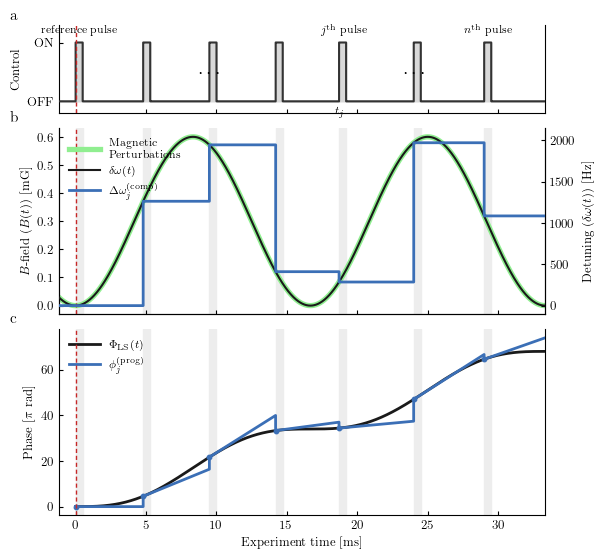

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

# extra time shown before t=0 (for B-field + detuning + trigger only)
pre_trigger_duration = 1.2e-3   # [s]

# optional trigger pulse shown in red before t=0
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG   (plays the role of \kappa in the theory text)

# Expanded pulse sequence so the control panel can show:
# reference pulse ... jth pulse ... nth pulse
pulse_times = np.array([
    0.01e-6,   # reference pulse, effectively at t = 0
    4.8e-3,
    9.5e-3,
    14.2e-3,
    18.7e-3,   # jth pulse
    24.0e-3,
    29.0e-3,   # nth pulse
], dtype=float)

pulse_width = np.full(len(pulse_times), 500e-6, dtype=float)

# first pulse is reference; compensation updates start from next pulse
first_update_index = 1

# indices used only for figure labeling
ref_pulse_index = 0
j_pulse_index = 4
n_pulse_index = len(pulse_times) - 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# =========================================================
# TIME AXES
# =========================================================
# full axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# phase axis starts at t=0 only
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# reference everything to the line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

# use only t >= 0 for phase accumulation
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

# sampled values at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# LASER DETUNING: piecewise constant, defined on full axis
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# LASER PHASE: piecewise linear + snaps, plotted only for t >= 0
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # [ms]
phase_laser_plot = np.array(phase_laser_plot)    # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

# optional red line-trigger pulse before t=0
trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.7),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 2.0, 2.0]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.20", lw=1.5, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.85", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.6, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.20, 1.30)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

# pulse labels
pulse_labels = {
    ref_pulse_index: r"reference pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

for idx, txt in pulse_labels.items():
    x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
    ax.text(x_center, 1.12, txt, ha="center", va="bottom", fontsize=8)

# mark t_j at the start of the jth pulse
ax.text(1e3 * pulse_times[j_pulse_index], -0.10, r"$t_j$", ha="center", va="top", fontsize=8)

# ellipses between reference -> jth and jth -> nth
x_ell_1 = 1e3 * 0.5 * (pulse_ends[ref_pulse_index] + pulse_times[j_pulse_index])
x_ell_2 = 1e3 * 0.5 * (pulse_ends[j_pulse_index] + pulse_times[n_pulse_index])

ax.text(x_ell_1, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)
ax.text(x_ell_2, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B-field + detuning
# ---------------------------------------------------------
ax = axs[1]
ax_r = ax.twinx()

ax.plot(
    t_full_ms, B_t_full,
    color="lightgreen", lw=3.8,
    label="Magnetic \n Perturbations", zorder=2, alpha=1
)

ax_r.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax_r.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax_r.set_ylabel(r"Detuning ($\delta\omega(t)$) [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: phase
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2, zorder=5)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # shade pulse windows only on lower panels
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # global t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL THEORY ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    # Panel 1 annotations
    axs[0].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.18, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

    # Panel 2 annotations
    idx1 = int(0.22 * len(t_full))
    axs[1].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idx1], B_t_full[idx1]),
        xytext=(t_full_ms[idx1] + 2.0, B_t_full[idx1] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idx2 = int(0.35 * len(t_full))
    ax_r.annotate(
        r"$\delta\omega(t)=\gamma B(t)$",
        xy=(t_full_ms[idx2], delta_ion_full[idx2]),
        xytext=(t_full_ms[idx2] + 2.5, delta_ion_full[idx2] + 130),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if first_update_index < len(pulse_times):
        j0 = first_update_index
        ax_r.annotate(
            r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
            xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
            xytext=(1e3 * pulse_times[j0] + 2.0, delta_pulses[j0] - 180),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    # Panel 3 annotations
    idx3 = int(0.45 * len(t))
    axs[2].annotate(
        r"$\Phi_{\mathrm{LS}}(t)=2\pi \!\int_0^t \delta\omega(t')\,dt'$",
        xy=(t_ms[idx3], phi_ion[idx3] / np.pi),
        xytext=(t_ms[idx3] + 1.5, phi_ion[idx3] / np.pi + 0.10),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if len(pulse_times) > first_update_index:
        j1 = min(first_update_index + 1, len(pulse_times) - 1)
        axs[2].annotate(
            r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
            xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
            xytext=(1e3 * pulse_times[j1] + 1.5, phi_pulses[j1] / np.pi + 0.15),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

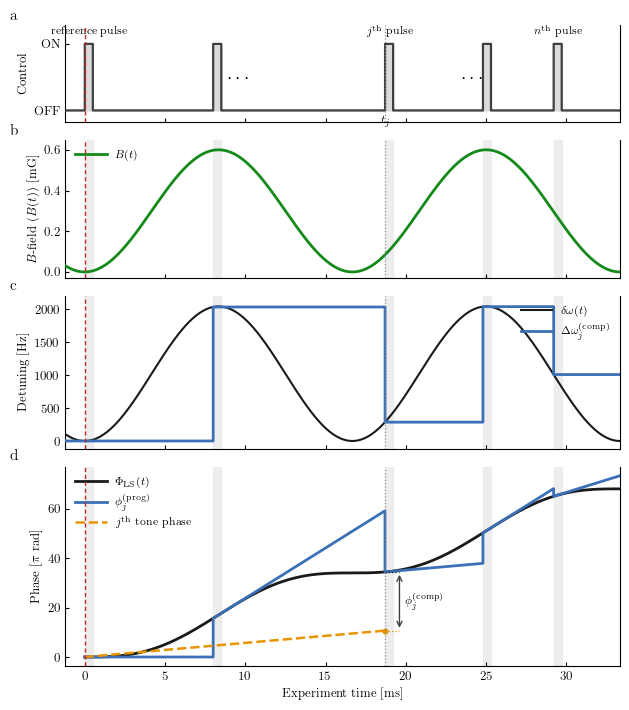

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

# extra time shown before t=0
pre_trigger_duration = 1.2e-3   # [s]

# optional trigger pulse shown in red before t=0
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG


# Pulse train used for the schematic:
# reference pulse ... jth pulse ... nth pulse
pulse_times = np.array([
    0.01e-6,   # reference pulse
    4.0e-3,
    8.7e-3,   # jth pulse
    24.8e-3,
    29.2e-3,   # nth pulse
], dtype=float)

pulse_width = np.full(len(pulse_times), 500e-6, dtype=float)

first_update_index = 1

# indices used for labeling in the schematic
ref_pulse_index = 0
j_pulse_index = 2
n_pulse_index = len(pulse_times) - 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
pulse_widths = np.asarray(pulse_width, dtype=float)
if len(pulse_widths) != len(pulse_times):
    raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# =========================================================
# TIME AXES
# =========================================================
# full axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# phase axis starts at t=0 only
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# reference everything to the line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

# detuning in Hz
delta_ion_full = gamma * B_t_full

# use only t >= 0 for phase accumulation
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

# sampled values at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# COMPENSATED LASER DETUNING: piecewise constant, full axis
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# PROGRAMMED PHASE: piecewise linear + snaps, plotted for t >= 0
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # [ms]
phase_laser_plot = np.array(phase_laser_plot)    # [rad]

# =========================================================
# JTH-TONE LINEAR PHASE IN THE REFERENCE FRAME
# This is the phase implied by using the jth compensated frequency,
# referenced back to t = 0.
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

# optional red trigger pulse before t=0
trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 1.35, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

# pulse labels
pulse_labels = {
    ref_pulse_index: r"reference pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

for idx, txt in pulse_labels.items():
    x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
    ax.text(x_center, 1.10, txt, ha="center", va="bottom", fontsize=8)

# mark t_j at the start of the jth pulse
ax.text(1e3 * pulse_times[j_pulse_index], -0.10, r"$t_j$", ha="center", va="top", fontsize=8)

# ellipses between reference -> jth and jth -> nth
x_ell_1 = 1e3 * 0.5 * (pulse_ends[ref_pulse_index] + pulse_times[j_pulse_index])
x_ell_2 = 1e3 * 0.5 * (pulse_ends[j_pulse_index] + pulse_times[n_pulse_index])
ax.text(x_ell_1, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)
ax.text(x_ell_2, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field only
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    label=r"$B(t)$", zorder=3
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning only
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

ax.set_ylabel(r"Detuning [Hz]")
ax.set_ylim(*padded_limits(np.r_[delta_ion_full, laser_detuning_full], low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

# linear phase of the jth compensated tone, referenced to t = 0
ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase", zorder=5
)

# marker at t_j
ax.plot(
    [t_j_ms],
    [2 * np.pi * delta_j * t_j / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# values at t_j
phi_ls_tj = np.interp(t_j, t, phi_ion)                 # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j              # [rad]

# slightly offset the arrow to the right of t_j so it does not sit on top of the vertical guide
x_arrow = t_j_ms + 0.9

# dotted horizontal guides from the two phase values to the arrow
ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

# double arrow showing the phase compensation
ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

# label for the phase correction
ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # shade pulse windows only on the lower three panels
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # global t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    # vertical guide at t_j
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL THEORY ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[0].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.18, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

    idxB = int(0.35 * len(t_full))
    axs[1].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idxB], B_t_full[idxB]),
        xytext=(t_full_ms[idxB] + 2.0, B_t_full[idxB] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idxD = int(0.32 * len(t_full))
    axs[2].annotate(
        r"$\delta\omega(t)$",
        xy=(t_full_ms[idxD], delta_ion_full[idxD]),
        xytext=(t_full_ms[idxD] + 2.0, delta_ion_full[idxD] + 180),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    axs[2].annotate(
        r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
        xy=(t_j_ms, delta_j),
        xytext=(t_j_ms + 1.2, delta_j + 180),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
        fontsize=8,
        bbox=label_box,
    )

    axs[3].annotate(
        r"$\Phi_{\mathrm{LS}}(t)$",
        xy=(t_j_ms, np.interp(t_j, t, phi_ion) / np.pi),
        xytext=(t_j_ms + 1.0, np.interp(t_j, t, phi_ion) / np.pi + 8),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    axs[3].annotate(
        r"$t\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, (2 * np.pi * delta_j * t_j) / np.pi),
        xytext=(t_j_ms - 9.0, (2 * np.pi * delta_j * t_j) / np.pi - 10),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=8,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

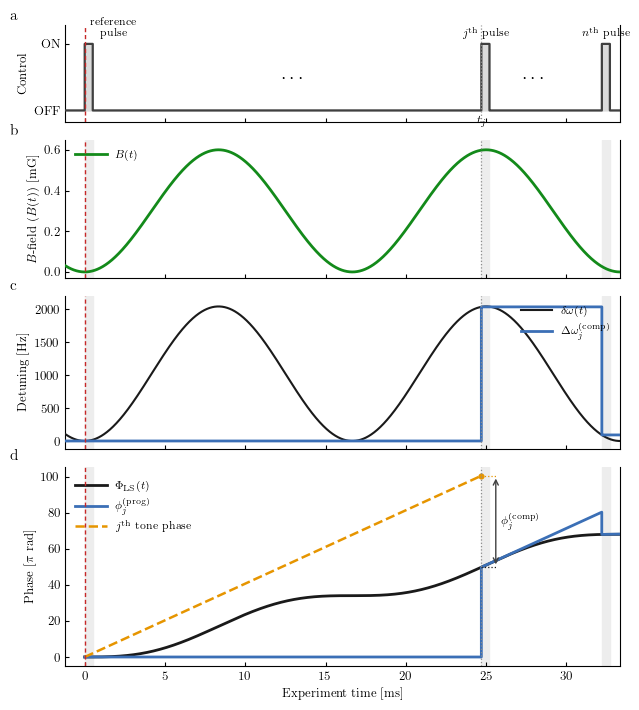

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
# Set pulse start times directly in ms.
# Number of pulses = len(pulse_times_ms)
pulse_times_ms = [
    0.00,   # reference pulse
    # 8.00,
    24.70,  # jth pulse
    32.20,  # nth pulse
]

# Common pulse width [ms], or list with one entry per pulse
pulse_width_ms = 0.50
# Example:
# pulse_width_ms = [0.50, 0.50, 0.70, 0.50]

# Choose which pulse is the jth pulse (0-based index)
j_pulse_index = 1

# Usually keep these:
ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

# Dot positions in ms (fully user-controlled)
dot_positions_ms = [13.0, 28.0]
dots_y = 0.52

# Labels for selected pulses
custom_pulse_labels = {
    ref_pulse_index: "reference \n pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

# First pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# COMPENSATED LASER DETUNING: piecewise constant
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# PROGRAMMED PHASE: piecewise linear + snaps
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# JTH-TONE LINEAR PHASE IN THE ω0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 1.35, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)

ax.text(1e3 * pulse_times[j_pulse_index], -0.10, r"$t_j$", ha="center", va="top", fontsize=8)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    label=r"$B(t)$", zorder=3
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

ax.set_ylabel(r"Detuning [Hz]")
ax.set_ylim(*padded_limits(np.r_[delta_ion_full, laser_detuning_full], low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase", zorder=5
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=8,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

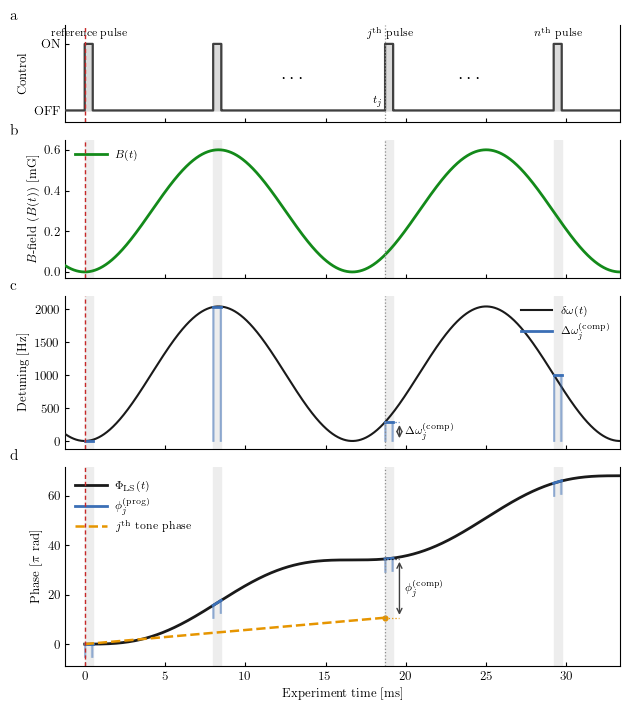

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

# Laser-edge styling for pulse-only plotting
SHOW_LASER_EDGE_DROPS = True
PHASE_DROP_HEIGHT_PI = 5.2      # visual drop height in units of pi rad
# DETUNING_DROP_FRACTION = 1.0   # 1.0 = full drop from 0 to delta_seg
EDGE_FADE_STEPS = 6
EDGE_FADE_WIDTH_MS = 0.10
EDGE_FADE_ALPHA = 0.28

# NEW:
# If True, show the blue laser detuning / laser phase only during pulse ON windows.
# If False, show the continuous conceptual version across the full sequence.
SHOW_LASER_ONLY_DURING_PULSES = True

pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
pulse_times_ms = [
    0.00,   # reference pulse
    8.00,
    18.70,  # jth pulse
    29.20,  # nth pulse
]

pulse_width_ms = 0.50
# Example:
# pulse_width_ms = [0.50, 0.50, 0.70, 0.50]

j_pulse_index = 2

ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

dot_positions_ms = [13.0, 24.0]
dots_y = 0.52

custom_pulse_labels = {
    ref_pulse_index: r"reference pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

# first pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

def draw_faded_vertical(ax, x, y0, y1, color, lw=1.2, steps=6, width_ms=0.10, alpha_max=0.28, direction="right", zorder=3):
    """
    Draw a soft vertical edge by stacking several nearby vertical lines
    with decreasing alpha.

    direction = "right"  -> fade extends to increasing x
    direction = "left"   -> fade extends to decreasing x
    """
    denom = max(steps - 1, 1)
    for k in range(steps):
        dx = width_ms * k / denom
        if direction == "left":
            dx = -dx
        alpha = alpha_max * (1 - k / denom)
        ax.plot(
            [x + dx, x + dx],
            [y0, y1],
            color=color,
            lw=lw,
            alpha=alpha,
            zorder=zorder,
        )

# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# CONTINUOUS CONCEPTUAL LASER DETUNING
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# CONTINUOUS CONCEPTUAL PROGRAMMED PHASE
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# PULSE-ONLY LASER DETUNING / PHASE SEGMENTS
# =========================================================
laser_detuning_pulse_only = np.full_like(t_full, np.nan)

pulse_phase_segments = []
pulse_detuning_segments = []

for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
    if j < first_update_index:
        delta_seg = 0.0
        phi_start_seg = 0.0
    else:
        delta_seg = delta_pulses[j]
        phi_start_seg = phi_pulses[j]

    # pulse-only detuning shown only while laser is ON
    if j < len(pulse_times) - 1:
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_pulse_only[mask] = delta_seg

    # pulse-only phase segment shown only while laser is ON
    nseg = max(40, int(fs * (t1 - t0)))
    t_seg = np.linspace(t0, t1, nseg, endpoint=True)
    phi_seg = phi_start_seg + 2 * np.pi * delta_seg * (t_seg - t0)

    pulse_phase_segments.append((1e3 * t_seg, phi_seg / np.pi))
    pulse_detuning_segments.append((1e3 * np.array([t0, t1]), np.array([delta_seg, delta_seg])))

# =========================================================
# JTH-TONE LINEAR PHASE IN THE ω0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 1.35, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

for idx, txt in custom_pulse_labels.items():
    x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
    ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)

ax.text(1e3 * pulse_times[j_pulse_index] - 0.5, 0.20, r"$t_j$", ha="center", va="top", fontsize=8)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    label=r"$B(t)$", zorder=3
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

if SHOW_LASER_ONLY_DURING_PULSES:
    first = True

    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        # horizontal segment only while laser is ON
        ax.plot(
            [x0, x1], [delta_seg, delta_seg],
            color=c_laser, lw=2.0,
            label=r"$\Delta\omega_j^{(\mathrm{comp})}$" if first else "_nolegend_",
            zorder=4
        )

        # soft turn-on / turn-off edges, fading to zero
        if SHOW_LASER_EDGE_DROPS and not np.isclose(delta_seg, 0.0):
            draw_faded_vertical(
                ax, x0, 0.0, delta_seg, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="right", zorder=3
            )
            draw_faded_vertical(
                ax, x1, delta_seg, 0.0, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="left", zorder=3
            )

        first = False

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms, laser_detuning_full,
        where="post",
        color=c_laser, lw=2.0,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":", lw=0.9, color=c_laser, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.35,
    0.5 * delta_j,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Detuning [Hz]")
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

if SHOW_LASER_ONLY_DURING_PULSES:
    first = True
    for xseg, yseg in pulse_phase_segments:
        ax.plot(
            xseg, yseg,
            color=c_laser, lw=2.0,
            label=r"$\phi_j^{(\mathrm{prog})}$" if first else "_nolegend_",
            zorder=4
        )

        if SHOW_LASER_EDGE_DROPS:
            x0, x1 = xseg[0], xseg[-1]
            y0, y1 = yseg[0], yseg[-1]

            draw_faded_vertical(
                ax, x0, y0 - PHASE_DROP_HEIGHT_PI, y0, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="right", zorder=3
            )
            draw_faded_vertical(
                ax, x1, y1, y1 - PHASE_DROP_HEIGHT_PI, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="left", zorder=3
            )

        first = False
else:
    ax.plot(
        phase_t_plot, phase_laser_plot / np.pi,
        color=c_laser, lw=2.0,
        label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
    )

ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase", zorder=5
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=8,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()